# Dynamic α-DPI Feature Extraction
### Per-Frame Geometric Parameter Inference from Time-Varying EHT Observations

---

This notebook demonstrates per-frame α-DPI inference on a time-varying black hole
observation, producing ridge plots that show how geometric parameter posteriors
evolve over time. This reproduces a result similar to Figure 13 of the EHT
Sgr A* Paper IV (2022, ApJL 930, L15).

**Contents**
1. [Setup & Data Loading](#1.-Setup-&-Data-Loading)
2. [Ground Truth Visualization](#2.-Ground-Truth)
3. [Load Precomputed Results](#3.-Load-Results)
4. [Ridge Plot](#4.-Ridge-Plot)
5. [Parameter Evolution](#5.-Parameter-Evolution)
6. [Posterior Images](#6.-Posterior-Images)
7. [Per-Frame Metrics](#7.-Metrics)
8. [Training from Scratch (Optional)](#8.-Training)

In [10]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

TASK_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if TASK_ROOT not in sys.path:
    sys.path.insert(0, TASK_ROOT)

from src.preprocessing import load_metadata
from src.generate_data import generate_simple_crescent_image
from src.visualization import (
    plot_ridge, plot_param_evolution, plot_frame_images,
    compute_frame_metrics, print_frame_metrics,
)

REF_DIR = os.path.join(TASK_ROOT, 'evaluation', 'reference_outputs')
OUT_DIR = os.path.join(TASK_ROOT, 'output')
print(f'Setup complete.')

Setup complete.


---
## 1. Setup & Data Loading

Load metadata describing the dynamic observation: 10 frames over 8 hours,
with the crescent position angle rotating from -130° to -50°.

In [11]:
metadata = load_metadata(os.path.join(TASK_ROOT, 'data'))

n_frames = metadata['n_frames']
npix = metadata['npix']
fov_uas = metadata['fov_uas']
frame_times = np.array(metadata['frame_times_hr'])
gt_per_frame = metadata['ground_truth_per_frame']

print(f'Frames           : {n_frames}')
print(f'Image            : {npix}x{npix}, FOV={fov_uas} \u03bcas')
print(f'Duration         : {metadata["obs_duration_hr"]} hr')
print(f'Frame interval   : {metadata["frame_duration_hr"]*60:.0f} min')
print(f'Geometric model  : {metadata["geometric_model"]}')
print(f'PA range         : {gt_per_frame[0]["position_angle_deg"]:.0f}\u00b0 \u2192 '
      f'{gt_per_frame[-1]["position_angle_deg"]:.0f}\u00b0')

Frames           : 10
Image            : 64x64, FOV=120.0 μas
Duration         : 8.0 hr
Frame interval   : 48 min
Geometric model  : simple_crescent
PA range         : -130° → -50°


---
## 2. Ground Truth Visualization

The ground truth is a simple crescent with fixed diameter, width, and asymmetry,
but a linearly rotating position angle.

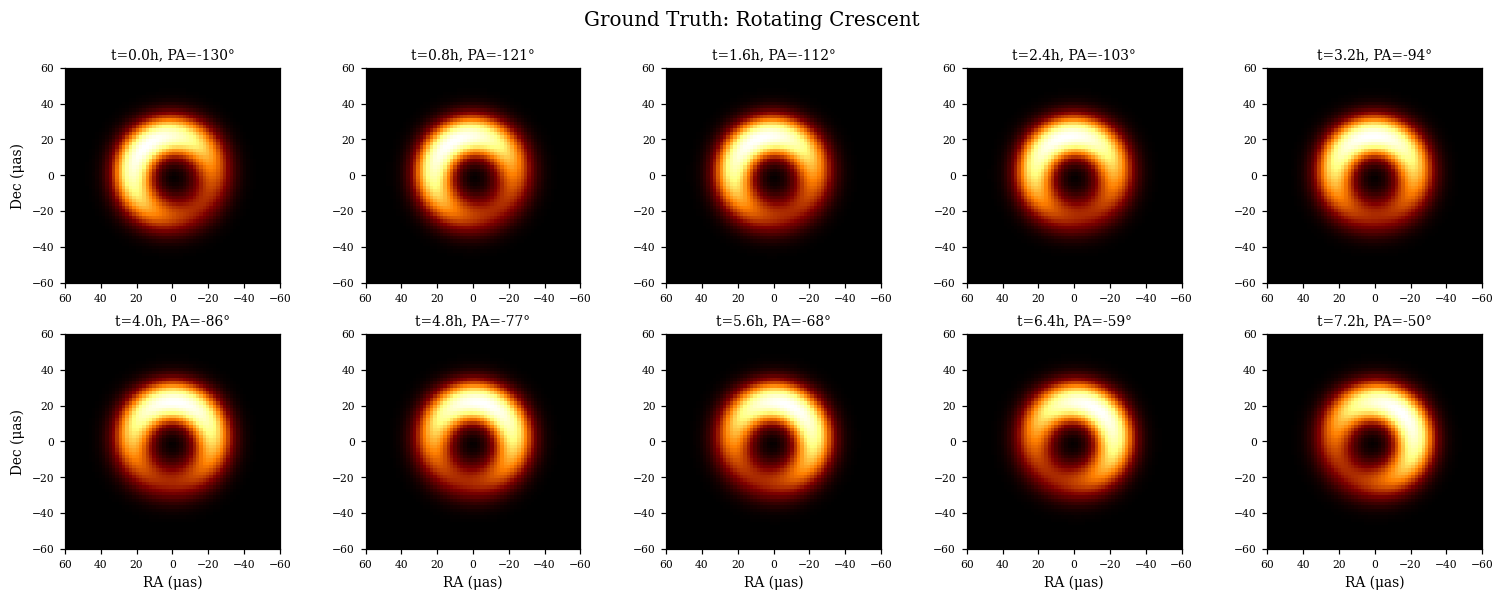

In [12]:
gt_images = []
for gt in gt_per_frame:
    img = generate_simple_crescent_image(
        npix, fov_uas, gt['diameter_uas'], gt['width_uas'],
        gt['asymmetry'], gt['position_angle_deg'])
    gt_images.append(img)

fig, axes = plt.subplots(2, 5, figsize=(14, 5.5))
half = fov_uas / 2
extent = [half, -half, -half, half]

for i, ax in enumerate(axes.flat):
    ax.imshow(gt_images[i], origin='lower', cmap='afmhot', extent=extent)
    pa = gt_per_frame[i]['position_angle_deg']
    ax.set_title(f't={frame_times[i]:.1f}h, PA={pa:.0f}\u00b0', fontsize=9)
    ax.tick_params(labelsize=7)
    if i % 5 == 0:
        ax.set_ylabel('Dec (\u03bcas)', fontsize=9)
    if i >= 5:
        ax.set_xlabel('RA (\u03bcas)', fontsize=9)

fig.suptitle('Ground Truth: Rotating Crescent', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Load Precomputed Results

Load the per-frame posterior samples and importance weights from a previous
pipeline run.

In [13]:
# Try reference_outputs first, then output/
for src_dir in [REF_DIR, OUT_DIR]:
    params_path = os.path.join(src_dir, 'all_params.npy')
    if os.path.exists(params_path):
        results_dir = src_dir
        break
else:
    raise FileNotFoundError('No precomputed results found. Run main.py first.')

all_params = np.load(os.path.join(results_dir, 'all_params.npy'))
all_weights = np.load(os.path.join(results_dir, 'all_weights.npy'))
all_images = np.load(os.path.join(results_dir, 'all_images.npy'))

# Convert to lists for visualization functions
params_per_frame = [all_params[i] for i in range(n_frames)]
weights_per_frame = [all_weights[i] for i in range(n_frames)]

print(f'Loaded results from: {results_dir}')
print(f'Samples per frame: {all_params.shape[1]}')
print(f'Parameters       : {all_params.shape[2]}')

for i in range(n_frames):
    w = all_weights[i] / all_weights[i].sum()
    n_eff = 1.0 / np.sum(w**2)
    print(f'  Frame {i}: N_eff = {n_eff:.0f}')

Loaded results from: /home/groot/Documents/PKUlab/imaging-101/tasks/eht_black_hole_feature_extraction_dynamic/evaluation/reference_outputs
Samples per frame: 10000
Parameters       : 4
  Frame 0: N_eff = 11
  Frame 1: N_eff = 51
  Frame 2: N_eff = 111
  Frame 3: N_eff = 22
  Frame 4: N_eff = 76
  Frame 5: N_eff = 19
  Frame 6: N_eff = 15
  Frame 7: N_eff = 22
  Frame 8: N_eff = 6
  Frame 9: N_eff = 4


---
## 4. Ridge Plot

Posterior parameter distributions at each time snapshot, displayed as stacked
density curves. Red dashed lines show ground truth values.

This is the key visualization, analogous to **Figure 13** of the EHT Sgr A*
Paper IV (2022). The PA subplot should show a clear diagonal trend
tracking the rotating bright spot.

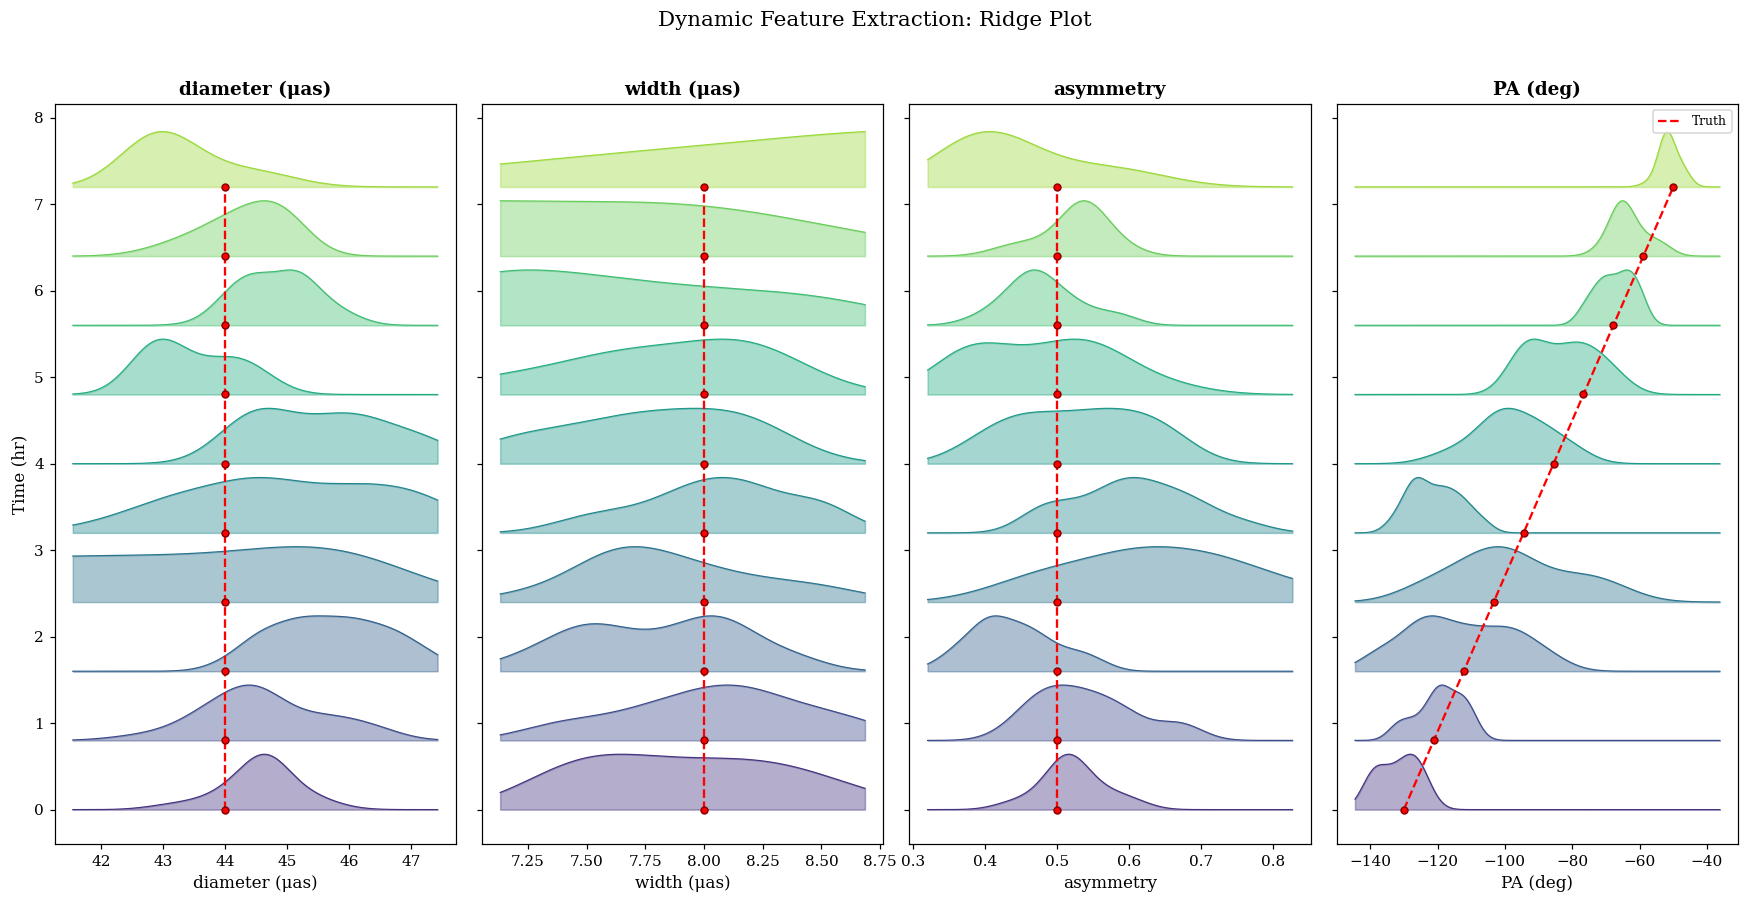

In [14]:
param_names = ['diameter (\u03bcas)', 'width (\u03bcas)', 'asymmetry', 'PA (deg)']

fig = plot_ridge(
    params_per_frame, param_names, gt_per_frame, weights_per_frame,
    frame_times)
plt.show()

---
## 5. Parameter Evolution

Importance-weighted posterior mean \u00b1 1\u03c3 vs ground truth over time.

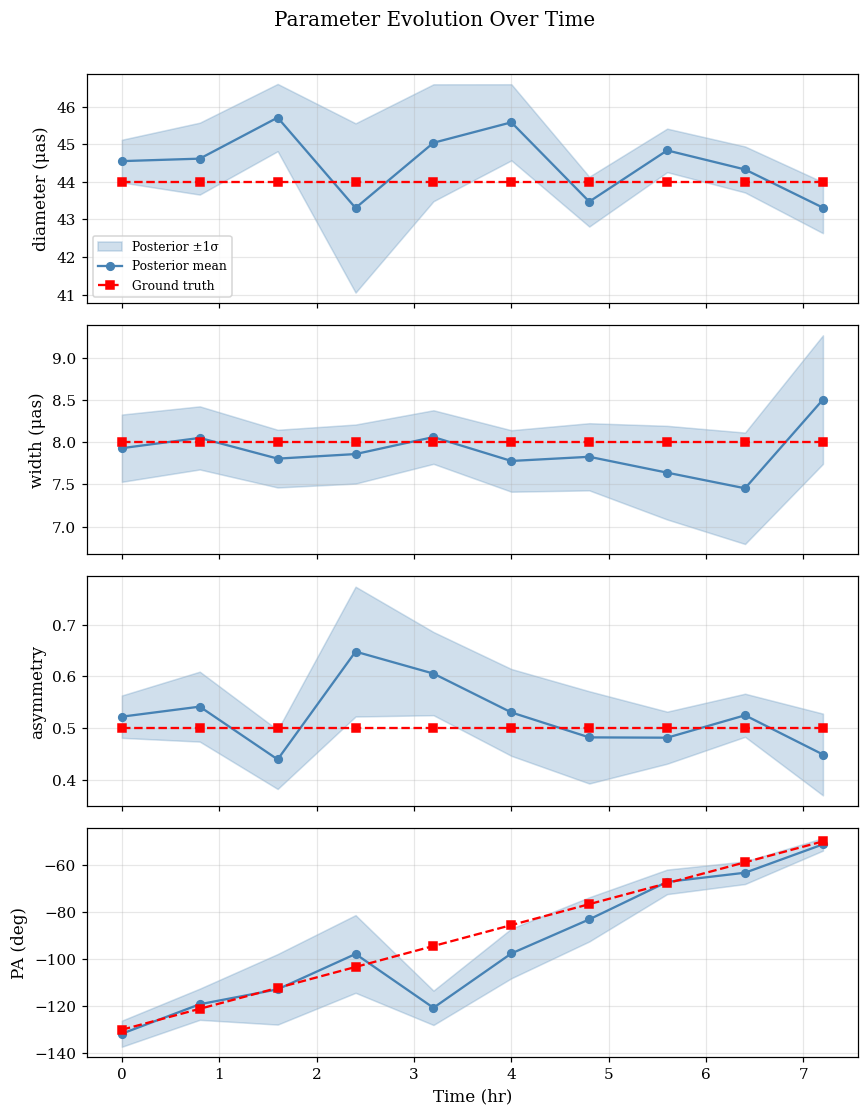

In [15]:
fig = plot_param_evolution(
    params_per_frame, param_names, gt_per_frame, weights_per_frame,
    frame_times)
plt.show()

---
## 6. Posterior Images

Posterior mean images (top row) vs ground truth (bottom row) for each frame.

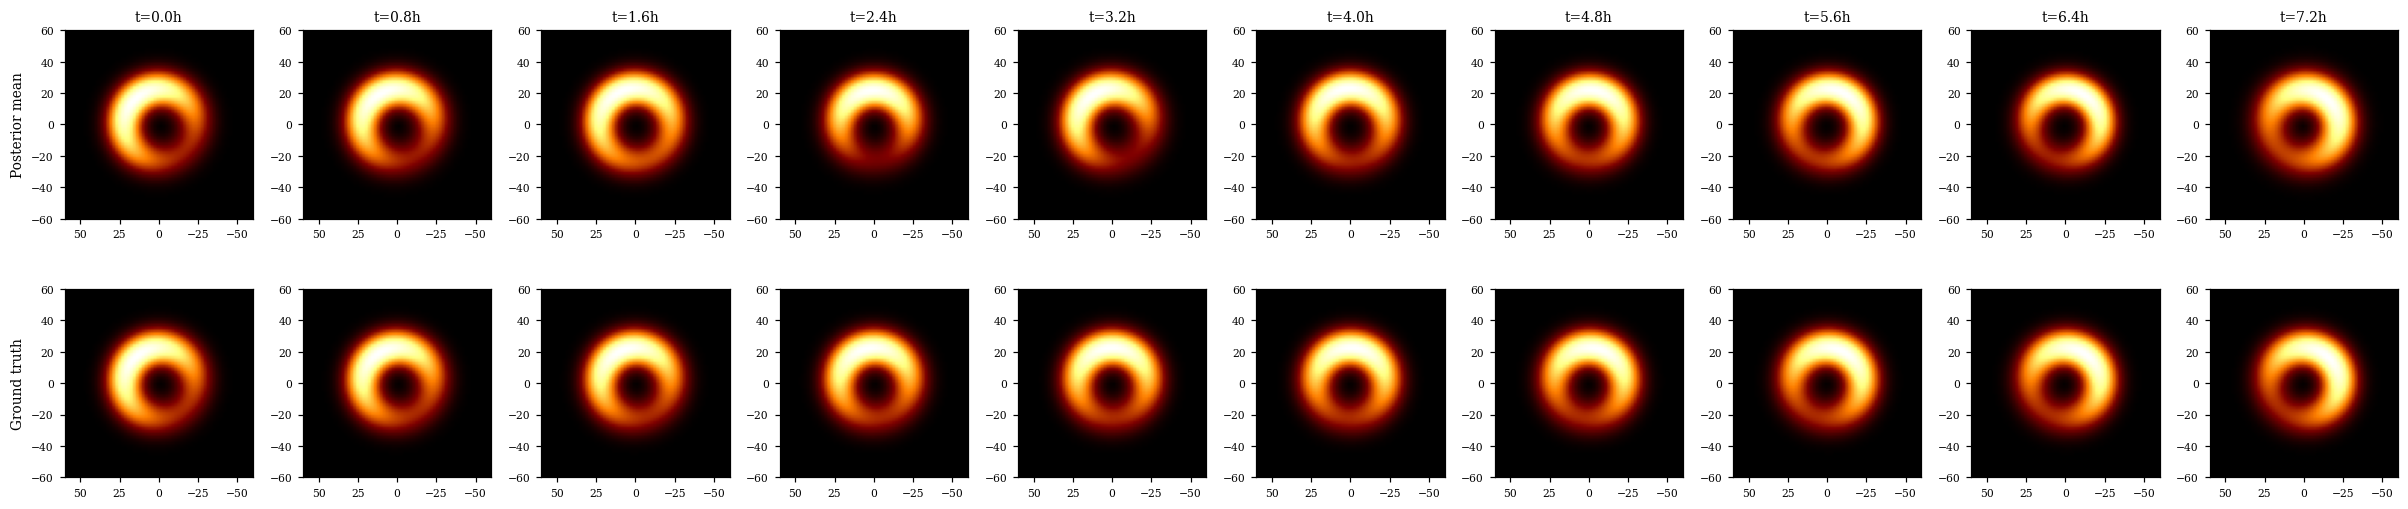

In [16]:
fig = plot_frame_images(
    all_images, frame_times,
    pixel_size_uas=fov_uas / npix,
    gt_images=gt_images)
plt.show()

---
## 7. Per-Frame Metrics

Importance-weighted posterior mean, standard deviation, and bias for each
parameter at each time frame.

In [17]:
metrics = compute_frame_metrics(
    params_per_frame, gt_per_frame, weights_per_frame, param_names)
print_frame_metrics(metrics)

Frame        diameter (μas)           width (μas)             asymmetry              PA (deg)
---------------------------------------------------------------------------------------------
    0    44.55±0.57 (+0.5)     7.93±0.40 (-0.1)     0.52±0.04 (+0.0)  -131.68±5.54 (-1.7)
    1    44.62±0.96 (+0.6)     8.05±0.37 (+0.0)     0.54±0.07 (+0.0)  -119.17±6.62 (+1.9)
    2    45.71±0.89 (+1.7)     7.80±0.34 (-0.2)     0.44±0.06 (-0.1)  -112.84±14.98(-0.6)
    3    43.30±2.25 (-0.7)     7.86±0.35 (-0.1)     0.65±0.13 (+0.1)   -97.82±16.50(+5.5)
    4    45.04±1.56 (+1.0)     8.06±0.32 (+0.1)     0.61±0.08 (+0.1)  -120.68±7.30 (-26.2)
    5    45.58±1.01 (+1.6)     7.78±0.36 (-0.2)     0.53±0.08 (+0.0)   -97.60±10.55(-12.0)
    6    43.47±0.66 (-0.5)     7.83±0.40 (-0.2)     0.48±0.09 (-0.0)   -83.13±9.39 (-6.5)
    7    44.83±0.58 (+0.8)     7.64±0.55 (-0.4)     0.48±0.05 (-0.0)   -67.20±5.21 (+0.6)
    8    44.33±0.61 (+0.3)     7.45±0.66 (-0.5)     0.52±0.04 (+0.0)   -63.32±4.81 (-4.4)


---
## 8. Training from Scratch (Optional)

Uncomment the cell below to run the full per-frame \u03b1-DPI pipeline.
This trains 10 independent models (~30-60 min total on GPU).

In [18]:
# # Uncomment to train from scratch:
# import torch
# from src.preprocessing import prepare_frame, load_raw_data
# from src.solvers import AlphaDPISolver
# 
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# raw_data = load_raw_data(os.path.join(TASK_ROOT, 'data'))
# 
# all_params_new = []
# all_weights_new = []
# all_images_new = []
# 
# for i in range(n_frames):
#     print(f'Frame {i}/{n_frames-1}...')
#     obs_data, closure_indices, nufft_params, flux_const = prepare_frame(
#         raw_data, i, npix, fov_uas)
#     
#     solver = AlphaDPISolver(
#         npix=npix, fov_uas=fov_uas,
#         n_flow=metadata['n_flow'],
#         seqfrac=1.0 / metadata.get('seqfrac_inv', 4),
#         n_epoch=metadata['n_epoch'],
#         batch_size=metadata['batch_size'],
#         lr=metadata['lr'],
#         geometric_model='simple_crescent',
#         n_gaussian=0,
#         device=device,
#     )
#     result = solver.reconstruct(obs_data, closure_indices, nufft_params, flux_const)
#     posterior = solver.importance_resample(
#         obs_data, closure_indices, nufft_params, n_samples=10000)
#     
#     all_params_new.append(posterior['params_physical'])
#     all_weights_new.append(posterior['importance_weights'])
#     all_images_new.append(posterior['weighted_mean_image'])

---
## Summary

| Aspect | Detail |
|--------|--------|
| **Method** | Per-frame \u03b1-DPI (independent inference per snapshot) |
| **Data** | Closure phases + log closure amplitudes (gain-invariant) |
| **Geometric model** | SimpleCrescent (4 params: diameter, width, asymmetry, PA) |
| **Architecture** | Real-NVP flow (16 blocks) \u2192 sigmoid \u2192 crescent model \u2192 NUFFT |
| **Array** | EHT 2017 (8 stations incl. SPT) |
| **Dynamic scenario** | PA rotates -130\u00b0 \u2192 -50\u00b0 over 8 hours (10 frames) |
| **Post-processing** | Importance sampling reweighting per frame |
| **Output** | Ridge plot showing parameter posterior evolution |

**References:**
- Sun et al. (2022), ApJ 932:99 \u2014 \u03b1-DPI
- EHT Collaboration (2022), ApJL 930:L15 \u2014 Sgr A* Paper IV (Figure 13)